In [1]:
!pip install gymnasium

   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/953.9 kB ? eta -:--:--
   ---------------------------------------- 953.9/953.9 kB 4.4 MB/s  0:00:00

   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   ---------------------------------------- 2/2 [gymnasium]



In [3]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [5]:
env = gym.make("Taxi-v4")

state, info = env.reset()

print("Number of States :", env.observation_space.n)
print("Number of Actions :", env.action_space.n)

Number of States : 500
Number of Actions : 6


In [6]:
state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

print(q_table.shape)

(500, 6)


In [7]:
learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 5000
max_steps = 100

In [8]:
rewards = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    done = False

    for step in range(max_steps):

        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward +
            discount_factor * np.max(q_table[next_state]) -
            q_table[state, action]
        )

        state = next_state

        total_reward += reward

        if done:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)

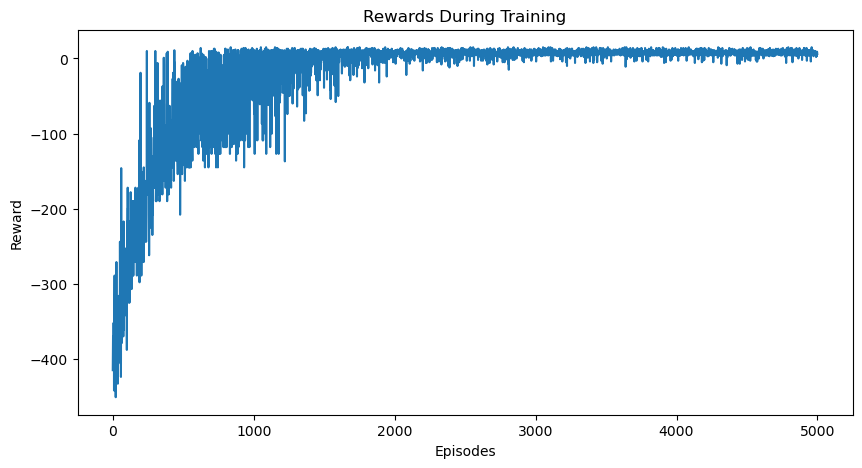

In [9]:
plt.figure(figsize=(10,5))

plt.plot(rewards)

plt.title("Rewards During Training")

plt.xlabel("Episodes")

plt.ylabel("Reward")

plt.show()

In [10]:
state, info = env.reset()

done = False

total_reward = 0

while not done:

    action = np.argmax(q_table[state])

    next_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    total_reward += reward

    state = next_state

print("Total Reward :", total_reward)

Total Reward : 6


In [11]:
print("Average Reward :", np.mean(rewards))

Average Reward : -21.1678


In [12]:
print(q_table)

[[ 0.          0.          0.          0.          0.          0.        ]
 [-2.91340027 -4.03095629 -3.9870189  -2.7402432   9.6220697  -8.0324353 ]
 [-1.65851661 -0.62577065 -2.19007184  0.71774912 14.11880599 -5.84295825]
 ...
 [-1.35599009 -0.9208122  -1.25184173 -1.40254925 -1.93688741 -4.85729119]
 [-2.83179989 -2.81359356 -2.75106176 -2.79918563 -6.01936975 -5.59116723]
 [-0.46332641 -0.41289187 -0.499001    1.511441   -4.13368031 -2.71      ]]


In [13]:
for state in range(20):
    print(f"State {state} --> Best Action : {np.argmax(q_table[state])}")

State 0 --> Best Action : 0
State 1 --> Best Action : 4
State 2 --> Best Action : 4
State 3 --> Best Action : 4
State 4 --> Best Action : 2
State 5 --> Best Action : 0
State 6 --> Best Action : 2
State 7 --> Best Action : 0
State 8 --> Best Action : 0
State 9 --> Best Action : 0
State 10 --> Best Action : 0
State 11 --> Best Action : 0
State 12 --> Best Action : 2
State 13 --> Best Action : 2
State 14 --> Best Action : 2
State 15 --> Best Action : 0
State 16 --> Best Action : 5
State 17 --> Best Action : 0
State 18 --> Best Action : 0
State 19 --> Best Action : 0
